# Module 4: Bivariate analysis - 2 qualitative variables

In this module and the two next ones, we will be exploring the *relationship between two variables*. Just like we saw in module 2 (analysis of one variable), the measurement level of the variables we are analyzing will determine the techniques we will use to explore their relationship. In this module, we will be looking at the relationship between two *qualitative* variables.

To demonstrate the concepts in this module, we import dataset `rlanders.csv`. It contains synthetic data that was generated randomly (see [the description](../data/rlanders.md)).

## Learning goals

By the end of this module, you should be able to:

- Understand the definitions and terminology (indicated with 💡) used in this notebook
- Select suitable techniques to analyze or visualize the relationship between two variables, depending on their measurement level
- Create and interpret a *contingency table* of two qualitative variables
- Create and interpret a *plot* of two qualitative variables (e.g. a stacked or grouped bar chart, or a mosaic plot)
- Calculate and interpret *Cramér's V* to measure the strength of association between two qualitative variables
- Perform a *chi-squared test of independence* to determine if there is a significant association between two qualitative variables
- Perform a *chi-squared goodness-of-fit test* to determine if the distribution of a qualitative variable differs from a specified distribution

## Bivariate analysis: introduction

In *bivariate analysis*, we want to determine whether there is an 💡**association** (also: **relationship**) between two stochastic variables $X$ and $Y$. We say that there is an association between $X$ and $Y$ if the value of one variable provides information about the value of the other variable. For example, if we know that a person is a smoker, this might provide information about their risk of developing lung cancer. In contrast, if there is no association between $X$ and $Y$, then knowing the value of one variable does not provide any information about the value of the other variable.

If we use the value of $X$ to predict the value of $Y$, then we say that $X$ is the 💡**independent variable** and that $Y$ is the 💡**dependent variable**.

Note that the choice of which variable is the (in)dependent variable is not always clear-cut, and it can depend on the context of the analysis. In some cases, there may be a bidirectional relationship between the two variables, where both variables can influence each other.

Also note that finding an association between two variables does not necessarily imply that there is a causal relationship between them (*"correlation is not causation"*). The direction of causation may not be clear from the data, or there may be another variable that is influencing both $X$ and $Y$, creating the appearance of an association between them when in reality there is no direct relationship.

This course is *not* an exhaustive discussion on the subject of bivariate analysis. Specifically, we will only focus on the techniques summarized below.

| **Independent** | **Dependent** |  **Test/Metric**                |
| :---:           | :---:         | :---                            |
| Qualitative     | Qualitative   | $\chi^2$-test/Cramér's $V$      |
| Qualitative     | Quantitative  | two-sample $t$-test/Cohen's $d$ |
| Quantitative    | Quantitative  | -/Regression, correlation       |

For visualizing the relationship between two variables, we will use the following plot types:

| **Independent** | **Dependent** |  **Plot**                                  |
| :---:           | :---:         | :---                                       |
| Qualitative     | Qualitative   | Grouped/stacked bar chart, mosaic plot     |
| Qualitative     | Quantitative  | Grouped boxplot, bar chart with error bars |
| Quantitative    | Quantitative  | Scatter plot, regression line              |


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

In [2]:
# Read dataset + data preparation
rlanders = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-en-labs/main/data/rlanders.csv').set_index(['ID'])
rlanders.Gender = rlanders.Gender.astype('category')
likert_scale = CategoricalDtype(categories=[1,2,3,4,5], ordered=True)
rlanders.Survey = rlanders.Survey.astype(likert_scale)
# rlanders.info()
# rlanders.Survey.dtype

## Contingency tables and visualisation techniques

Qualitative variables have a limited number of possible values (categories). We usually summarize the distribution of a qualitative variable using a *frequency table*. When we want to analyze the relationship between two qualitative variables, we can use a 💡**contingency table** (also: *cross-tabulation* or 💡**crosstab**). A contingency table is a tabular representation of the joint distribution of two categorical variables. It shows the frequency (or proportion) of observations for each combination of categories of the two variables.

Let's say we want to know whether women and men (variable `Gender`) within the sample have responded differently on a survey question with a Likert scale (variable `Survey`). 

If the proportions of the answers (1 to 5) for women and men are about the same, we say that there is no association between the two variables. If there is a significant difference, then there is an association. Now, of course, the question is when is the difference large enough to be considered *significant*...

A first step is to calculate a contingency table. The *independent* variable `Gender` is used to create the colums (second parameter), and the *dependent* variable `Survey` is used to create the rows (first parameter). We immediately add the 💡**marginal totals**, i.e., the sums of the rows and columns:

In [3]:
pd.crosstab(rlanders.Survey, rlanders.Gender, margins=True)

Gender,Female,Male,All
Survey,,,
1,0,4,4
2,17,45,62
3,23,91,114
4,12,53,65
5,0,5,5
All,52,198,250


### Clustered bar chart

Of course, a table with numbers does not say much at first glance. Perhaps we should visualise the data, e.g. with a clustered bar chart.

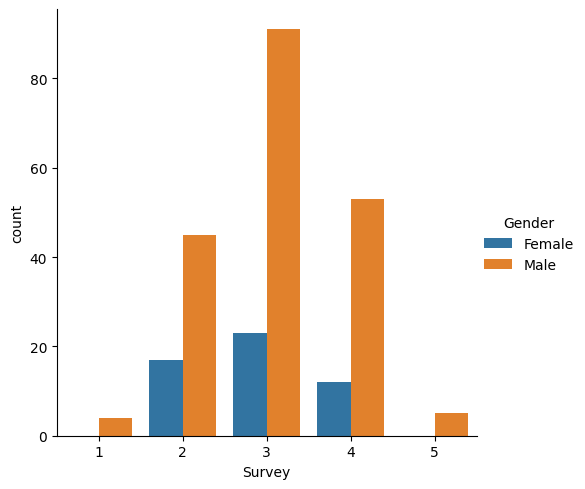

In [4]:
sns.catplot(data=rlanders, x='Survey', hue='Gender', kind='count');

Remark that we mapped the *independent* variable `Gender` to the `hue` parameter and the *dependent* variable `Survey` to the `x` parameter.

If the "shape" of the bars for both categories is similar, we can conclude that both categories have a similar distribution, or that there is no association between the two variables. If the shape were different (e.g. highest peak for men at 2 and for women at 4), that would indicate that there actually is an association, or that men and women give significantly different answers to the survey question.

In this case, what is striking is that the women did not give the extreme answers (1 or 5). However, there are considerably fewer women in the sample, so that may be just a coincidence, not necessarily a significant pattern.

### Stacked bar chart

Another way to visualize the data is by stacking the bars instead of clustering them. Unfortunately, Seaborn doesn't provide us with a convenient method to do so. However, a crosstab object (actually a Pandas DataFrame) has a plot method that we can use. Remark that we swapped the variables when calling the crosstab function, so the *independent* variable `Gender` is now the row and the *dependent* variable `Survey` is the column.

In [5]:
pd.crosstab(rlanders.Gender, rlanders.Survey)

Survey,1,2,3,4,5
Gender,,,,,
Female,0,17,23,12,0
Male,4,45,91,53,5


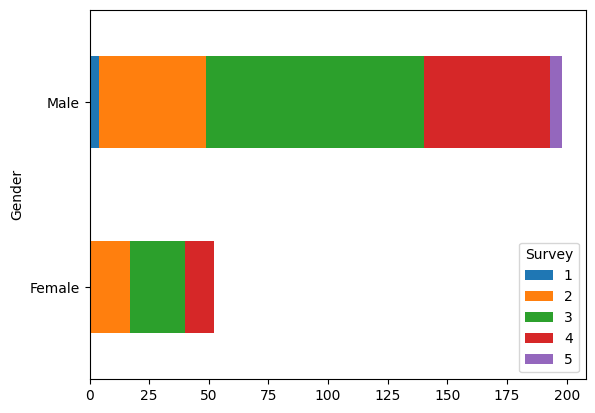

In [6]:
# Contingency table without the margins
observed = pd.crosstab(rlanders.Gender, rlanders.Survey)

# Horizontally oriented stacked bar chart
observed.plot(kind='barh', stacked=True);

We want to compare the proportions within each category (Male, Female) that replied to the survey question. In data sets with large differences in the number of observations for each category, this representation is still difficult to interpret. By looking at the *relative* frequencies (i.e. percentages), we may get a better result:

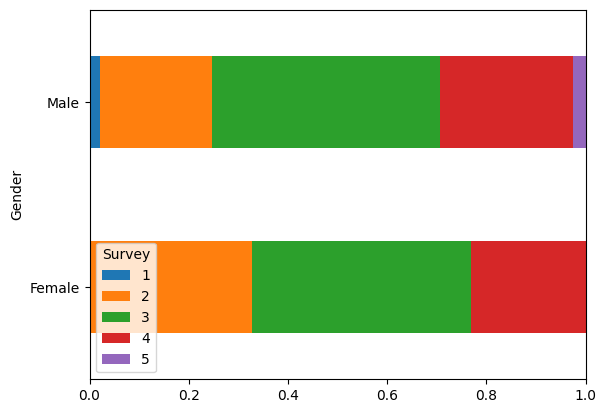

In [7]:
# Contingency table with proportions (normalized by row)
observed_p = pd.crosstab(rlanders.Gender, rlanders.Survey, normalize='index')

# Horizontally oriented stacked bar chart
observed_p.plot(kind='barh', stacked=True);

We can see that there are some differences between the proportions, e.g. the percentage of women answering "2" (orange) seems larger than the men. Whether this is a significant difference remains to be seen (see below for further analysis of this case).

In this representation we lose the information about the number of men and women in the sample. Specifically, we don't see that there are much less women. A mosaic diagram solves this problem.

### Mosaic diagram
A mosaic diagram is a graphical representation of the crosstab where each cell is represented by a tile whose area is proportional to the frequency of that cell with respect to the total number of observations.

You can compare this a bit with how [WinDirStat](https://windirstat.net/) visualises the size of files on your hard disk.

For this case:

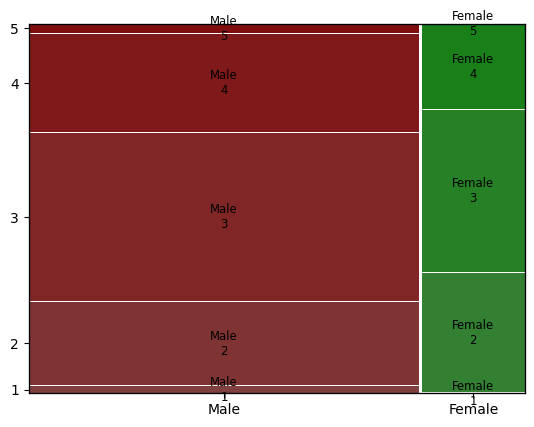

In [8]:
# Mosaic diagram with default settings
mosaic(
    data=rlanders.sort_values(by=['Survey']),
    index=['Gender', 'Survey']);

The colors in the mosaic diagram are not very informative, so we give another example where the colors are based on the `Survey` values instead. Unfortunately, this involves creating a function that maps the `Survey` values to colors, which is a bit more work. The result is shown below:

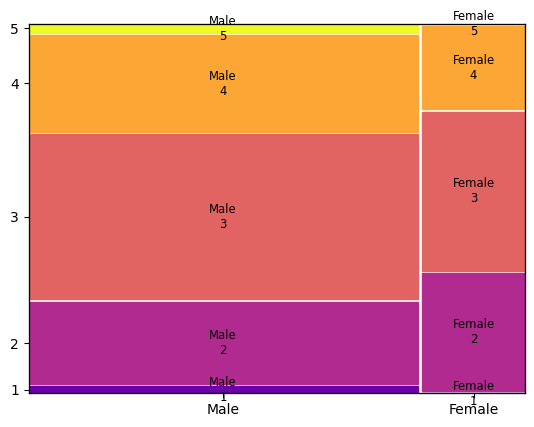

In [9]:
import matplotlib as mpl

# By default, mosaic() will color all columns the same. Here,
# we're going to give a separate color to each response (1-5).
# The response is kept in the label of each cell, a tuple of
# the two values that are represented in that cell (e.g. 
# ('Female', '2')). We will be using the "plasma" color map
# in this example.
plasma_colors = mpl.colormaps['plasma']
# Create a function that maps the cell key to the color we
# want to give it. We use the colormap function created above
# and give it a number between 0 and 1. We convert the second
# part of the key (values '1' to '5') to a number and divide
# by 5.
props = lambda key: {'color': plasma_colors(int(key[1])/5)}

mos_gender_survey = mosaic(
       data=rlanders.sort_values(by=['Survey']),
       index=['Gender', 'Survey'],
       gap=0.01, properties=props);

We can clearly see here that there are more men in the sample (wider tiles).

You can also compare the distributions of the answers given to the survey question. Except for the fact that the women did not give extreme answers (1 and 5), at first sight, the distributions still seem to match quite well.

## Chi-squared and Cramér's V

**Chi-squared** ($\chi^2$) and **Cramér's V** are statistics that can help us to determine whether there is an association between two qualitative (categorical) variables.

The reasoning goes as follows: if there is *no* association between `Gender` and `Survey`, then we expect the proportions of the values of `Survey` to be the same for all values of `Gender`. In other words, for both women and men, the same percentage of respondents will give the same answer to the question.

In [10]:
# As a reminder, here is the contingency table with marginal totals again:
pd.crosstab(rlanders.Survey, rlanders.Gender, margins=True)

Gender,Female,Male,All
Survey,,,
1,0,4,4
2,17,45,62
3,23,91,114
4,12,53,65
5,0,5,5
All,52,198,250


In [11]:
observed = pd.crosstab(rlanders.Survey, rlanders.Gender)
row_sums = observed.sum(axis=1)
col_sums = observed.sum()
n = row_sums.sum()

Now we can calculate how often we can expect each combination of `Gender` and `Survey` to occur in the sample. For example, 114 out of 250 respondents answered "3", i.e. 114/250 = 0.456 (or 46.6%). Then we expect that both 46.6% of the women and 46.6% of the men would have answered "3". Since there were 52 female respondents, we expect that 52 x 0.456 = 23.712 have answered "3". In reality, there were 23. For the men, we expect 198 x 0.456 = 90.288 (compared to 91 in reality).

Applying the same principle to all cells in the table, we can calculate the expected frequencies using the formula: $\frac{row total \times column total}{n}$ (with $n$ the total number of observations).

The `numpy` function `outer()` can be leveraged to calculate the expected frequencies for all cells in the table at once like this:

In [12]:
expected = np.outer(row_sums, col_sums) / n
expected

array([[ 0.832,  3.168],
       [12.896, 49.104],
       [23.712, 90.288],
       [13.52 , 51.48 ],
       [ 1.04 ,  3.96 ]])

In this table, the marginal totals should still sum to the same values as before. Let's check if that is the case:

In [13]:
exp_row_sums = np.sum(expected, axis=1)
exp_col_sums = np.sum(expected, axis=0)

print(f'Row totals   : {exp_row_sums}')
print(f'Column totals: {exp_col_sums}')
print(f'Observations : {exp_col_sums.sum()}')

Row totals   : [  4.  62. 114.  65.   5.]
Column totals: [ 52. 198.]
Observations : 250.0


Indeed, they do. Now, what's the difference between the expected and observed values?

In [14]:
expected - observed

Gender,Female,Male
Survey,,
1,0.832,-0.832
2,-4.104,4.104
3,0.712,-0.712
4,1.520,-1.520
5,1.040,-1.040


Some observed values seem to be close to the expected ones (e.g. for "3"), others are further away (e.g. "2"). However, we must also see the differences in proportion. So just calculating the differences between observed and expected values is not very informative.

A measure for determining the overall deviation in a frequency table from the expected values is to square the differences between expected and observed values (just as one does with variance/standard deviation) and divide by the expected value:

In [15]:
diffs = (expected - observed)**2 / expected
print(diffs)

Gender    Female      Male
Survey                    
1       0.832000  0.218505
2       1.306050  0.343003
3       0.021379  0.005615
4       0.170888  0.044880
5       1.040000  0.273131


The sum of all these values is notated 💡$\chi^2$ ("**chi-squared**", using the Greek letter *chi*):

$\chi^2 = \sum_i \frac{(o_i - e_i)^2}{e_i}$

with $o_i$ the number of observations in the $i$'th cell of the contingency table and $e_i$ the expected frequency. Compare the formula with the code above to find similarities!

In [16]:
chi_squared = diffs.values.sum()
print('χ² ≈ %.3f' %chi_squared)

χ² ≈ 4.255


The closer $\chi^2$ is to 0, the closer the observed values are to the expected values, and thus the weaker the association between the two variables. The larger $\chi^2$, the stronger the association.

Now, this value in itself *still* does not say very much. Under what conditions do we say that there is or isn't an association between the two variables? That will also depend on the size of the table and the total number of observations. In a contingency table with more rows/columns, you will need a larger $\chi^2$ before you can conclude that there is an association.

💡[**Cramér's V**](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V) is a formula that normalises $\chi^2$ to a value between 0 and 1 that is independent of the table size.

$V = \sqrt{\frac{\chi^2}{n(k-1)}}$

with $n$ the total number of observations and $k$ the number of rows or columns (whichever is smaller).

In [17]:
cramers_v = np.sqrt(chi_squared / ((min(observed.shape) - 1) * n))
cramers_v

np.float64(0.13046762087242633)

The value of Cramér's $V$ can also be calculated with the following Python function (from the `scipy.stats` module):

In [18]:
stats.contingency.association(observed, method='cramer')

0.13046762087242636

To draw a conclusion from this figure, compare it with the values in the table below:

| Cramér's V | Interpretation          |
| :---:      | :---                    |
| 0          | No association          |
| 0.1        | Weak association        |
| 0.25       | Moderate association    |
| 0.50       | Strong association      |
| 0.75       | Very strong association |
| 1          | Complete association    |

So our result for Cramér's V indicates a fairly weak association. Note that in certain cases, Cramér's V is known to be too optimistic about the association between two variables. There is a modified formula for eliminating this bias, but it is beyond the scope of this course.

There is, however, another way to determine whether the chi-square is large enough to conclude that there is a relationship, namely by means of a statistical test.

## The chi-squared test for independence

To answer the question of when the value of chi-square is sufficient to assume an association between two variables, we can use the *chi-square independence test*.

### The chi-squared distribution

The value of $\chi^2$ follows a specific stochastic distribution that is called the 💡$\chi^2$**-distribution**. Just like with the Student-t distribution, the shape of the probability density function depends on the degrees of freedom, which in this context is $df = (r-1)\times(k-1)$ (with $r$ the number of rows in the contingency table and $k$ the number of columns).

Some useful Python functions:

| Function | Description |
| :---:    | :---        |
| `stats.chi2.pdf(x, df)` | Probability density function |
| `stats.chi2.cdf(x, df)` | Left-tail probability $P(X < x)$ |
| `stats.chi2.sf(x, df)`  | Right-tail probability $P(X > x)$ |
| `stats.chi2.isf(q, df)` | $q$ percent of observations exceed this value |

The code below plots the probability density function of the $\chi^2$-distribution for some values of degrees of freedom:

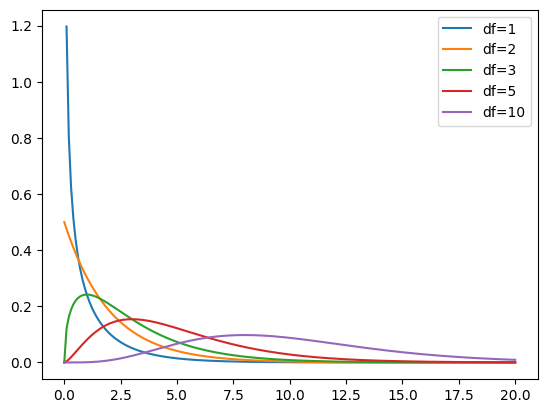

In [19]:
# Plot of the chi-squared distribution for different degrees of freedom
x = np.linspace(0, 20, num=200)
plt.plot(x, stats.chi2.pdf(x, 1), label="df=1");
plt.plot(x, stats.chi2.pdf(x, 2), label="df=2");
plt.plot(x, stats.chi2.pdf(x, 3), label="df=3");
plt.plot(x, stats.chi2.pdf(x, 5), label="df=5");
plt.plot(x, stats.chi2.pdf(x, 10), label="df=10");
plt.legend(loc='best');

Using this figure, you can follow a reasoning similar to a right-sided z-test. You can calculate a **critical value** $g$ for which the area under the curve to the right of $g$ is equal to our chosen significance level $\alpha$. If the **test statistic** $\chi^2$ is greater than $g$, we say that the deviations from the expected values in the contingency table are too large to be coincidental and that we have reason to believe that there is an association between the two variables.

You can also calculate the **excess probability** $p$, i.e. the probability that the deviations you see in the sample could be due to random sampling errors. To do this, you calculate the area under the density curve to the right of $p$. If this area is smaller than $\alpha$, we also say that the deviations are too large to be caused by random sampling errors and that there is therefore an association between the variables.

In Python, we can use the following Scipy functions for this purpose:

- `stats.chi2.sf(x)` - the right tail probability of `x` (or survival function)
- `stats.chi2.isf(q)` - the inverse function of `sf(x)`, i.e. calculate a number `x` for which the right tail probability is exactly `q`.

A plot for the case where $\alpha = 0.05$ (an often chosen value for the significance level) and 4 degrees of freedom:

Critical value ≃ 9.488


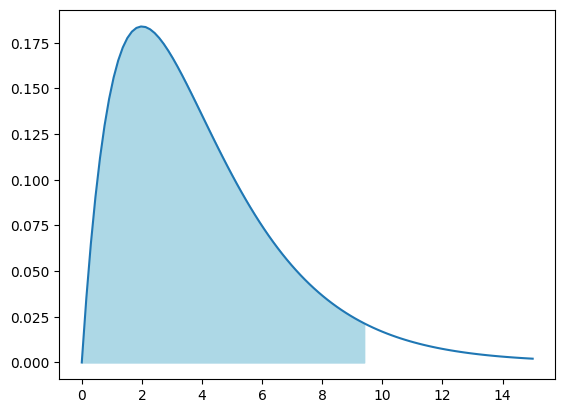

In [20]:
# Right tail probability in the chi-squared distribution

# x-values:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with 4 degrees of freedom
y = stats.chi2.pdf(x, df=4)
# the critical value g for which the right tail probability is exactly 5%:
g = stats.chi2.isf(.05, df=4)
print(f'Critical value ≃ {g:.3f}');

plt.plot(x, y)                      # probability density
plt.fill_between(x, y, where=x<=g,  # region of acceptance
    color='lightblue');

### Test procedure

Formally, the procedure of the 💡$\chi^2$ **test for independence** runs as follows:

1. Formulate the hypotheses:
   - $H_0$: There is no association between the variables (the differences between observed and expected values are small)
   - $H_1$: There is an association between the variables (the differences are large)
2. Choose significance level $\alpha$
3. Calculate the value of the test statistic in the sample (here: $\chi^2$).
4. Use one of the following methods (based on the degrees of freedom $df = (r-1) \times (k-1)$):
   1. Determine critical value $g$ so $P(\chi^2 > g) = \alpha$
   2. Calculate the $p$-value
5. Draw a conclusion based on the outcome:
   1. $\chi^2 < g$: do not reject $H_0$; $\chi^2 > g$: reject $H_0$
   2. $p > \alpha$: do not reject $H_0$; $p < \alpha$: reject $H_0$

In Python, we can calculate this as follows:

In [21]:
alpha = .05
dimensions = observed.shape
dof = (dimensions[0]-1) * (dimensions[1]-1)

print("Chi-squared        : %.4f" % chi_squared)
print("Degrees of freedom : %d" % dof)

# Calculate critical value
g = stats.chi2.isf(alpha, df = dof)
print("Critical value     : %.4f" % g)

# Calculate p-value
p = stats.chi2.sf(chi_squared, df=dof)
print("p-value            : %.4f" % p)

Chi-squared        : 4.2555
Degrees of freedom : 4
Critical value     : 9.4877
p-value            : 0.3725


Actually, we do not need to memorise these formulas to determine chi-square, the critical value and the p-value. SciPy already has a function that allows us to calculate the chi-square and p-value directly from a contingency table:

In [22]:
# Chi-squared test for independence based on a contingency table
observed = pd.crosstab(rlanders.Survey, rlanders.Gender)
chi2, p, df, expected = stats.chi2_contingency(observed)

print("Chi-squared       : %.4f" % chi2)
print("Degrees of freedom: %d" % df)
print("P-value           : %.4f" % p)

Chi-squared       : 4.2555
Degrees of freedom: 4
P-value           : 0.3725


As you can see, the outcome for the $p$-value is the same as in our worked out calculations!

A graphical representation of our case:

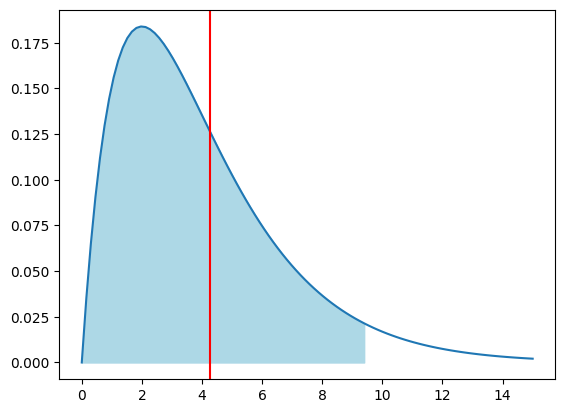

In [23]:
# Is there an association between Gender and Survey?

# x-values:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with 4 degrees of freedom
y = stats.chi2.pdf(x, df=dof)
# the critical value g for which the right tail probability is exactly 5%:
g = stats.chi2.isf(alpha, df=dof)

plt.plot(x, y);                     # probability density
plt.fill_between(x, y, where=x<=g,  # critical area
    color='lightblue');
plt.axvline(chi2, color='red');  # chi-squared

We see that $\chi^2$ is well within the region of acceptance. The $p$-value is also greater than $\alpha$. Consequently, we cannot reject the null hypothesis and conclude that, based on this sample, there is no reason to believe that there is a significant difference between women's and men's answers to the survey question.

## Goodness-of-fit test

A variant of the chi-squared test is the 💡**goodness-of-fit** test. This test is used to determine whether the distribution of a single categorical variable in a sample matches a specified distribution (e.g., a theoretical distribution or the distribution in the population). Consequently, this test can be used to check if a sample of data is representative of the population from which it was drawn, at least with respect to the distribution of a particular categorical variable.

Suppose that in a sample consisting of respondents to a survey, we keep track of what age group they belong to and that we also know how often each age group occurs in the entire population (as a percentage). Given below are the absolute frequencies in the sample $o_i$ and the expected relative frequencies $\pi_i$ in the population:

In [24]:
# Age groups=           18-25  26-35  36-45  46-55  56+
observed =   np.array([   75,    98,   127,    73,  27])
expected_p = np.array([  .17,   .23,   .35,   .17, .08])

The question now is: is this sample representative of the population? Does each age group occur in the sample in proportion to the expected percentage in the population as a whole?

### Test procedure

To answer these kinds of questions, a goodness-of-fit test is suitable. The procedure is as follows:

1. Formulate the hypotheses:
   - $H_0$: The sample is representative of the population, i.e. the frequency of each class within the sample corresponds well to that in the population.
   - $H_1$: The sample is *not* representative of the population, i.e. the differences with the expected frequencies are too large.
2. Choose significance level $\alpha$
3. Calculate the value of the test statistic in the sample (here: $\chi^2$).
4. Use one of the following methods (based on the degrees of freedom $df = (k-1)$ with $k$ the number of categories in the sample):
   1. Determine critical value $g$ so $P(\chi^2 > g) = \alpha$
   2. Calculate the $p$-value
5. Draw a conclusion based on the outcome:
   1. $\chi^2 < g$: do not reject $H_0$; $\chi^2 > g$: reject $H_0$
   2. $p > \alpha$: do not reject $H_0$; $p < \alpha$: reject $H_0$

A plot of this case, including the calculation of $p$ and $g$:

In [25]:
alpha = 0.05               # Significance level
n = sum(observed)          # Sample size
k = len(observed)          # Number of categories
dof = k - 1                # Degrees of freedom
expected = expected_p * n  # Expected absolute frequencies in the sample
g = stats.chi2.isf(alpha, df=dof)  # Critical value

# Goodness-of-fit-test in Python:
chi2, p = stats.chisquare(f_obs=observed, f_exp=expected)

print("Significance level  ⍺ = %.2f" % alpha)
print("Sample size         n = %d" % n)
print("k = %d; df = %d" % (k, dof))
print("Chi-squared        χ² = %.4f" % chi2)
print("Critical value      g = %.4f" % g)
print("p-value             p = %.4f" % p)

Significance level  ⍺ = 0.05
Sample size         n = 400
k = 5; df = 4
Chi-squared        χ² = 3.4679
Critical value      g = 9.4877
p-value             p = 0.4828


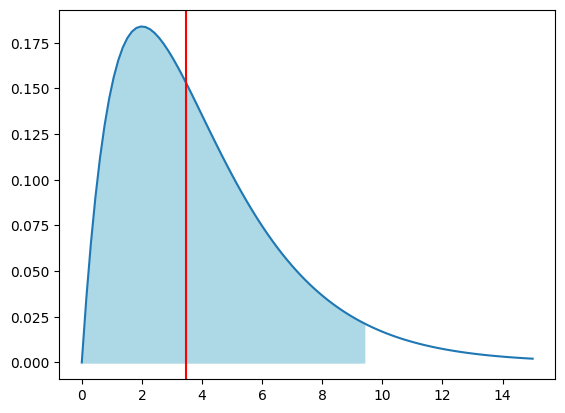

In [26]:
# Plot of the case:
# x-values:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with 4 degrees of freedom
y = stats.chi2.pdf(x, df=dof)
# the critical value g for which the right tail probability is exactly 5%:
g = stats.chi2.isf(alpha, df=dof)

plt.plot(x, y)                     # probability density
plt.fill_between(x, y, where=x<=g, # critical area
    color='lightblue')
plt.axvline(chi2, color='red');    # chi-squared

We can see that $\chi^2$ in the sample is left of the critical value, so within the area of acceptance. Therefore, we cannot reject the null hypothesis and can conclude that the sample is representative for the population, at least w.r.t. the age groups.

## Standardised residuals

After performing a chi-squared test, it is often also interesting to know in which categories the largest deviations occur. You could look at the value $\frac{(o-e)^2}{e}$ for each cell in the contingency table (or vector), which is used in the calculation of $\chi^2$. However, from this you cannot tell to what extent the deviations can really be considered "extreme". For this we use so-called 💡**standardised residuals**.

We introduce this concept by means of an example:

Suppose that a certain study looks at families with 5 children. A sample of 1022 families is taken, and they are divided into categories according to the number of boys in the family. The frequencies are given below in a Pandas DataFrame that we will create manually and systematically extend.

In [27]:
# Data frame with 2 columns:
#  - number of boys in the family (index)
#  - number of families in the sample with that number of boys
families = pd.DataFrame(
    np.array(
        [[0,  58],
         [1, 149],
         [2, 305],
         [3, 303],
         [4, 162],
         [5,  45]]),
    columns=['num_boys', "observed"])
families.set_index(['num_boys'])
n = families.observed.sum() # sample size

Now what is the expected number of families with the given number of boys? Let's assume that the probability of conceiving boys or girls is equally large, i.e. 0.5. In that case, we can calculate the expected relative frequencies with this formula:

$\pi_i = (0.5)^i (1-0.5)^{5-i} \binom{5}{i}$

Why that is the case is not relevant for the subject at hand and is beyond the scope of this course.

The expected absolute frequencies in the sample can then be calculated as $e_i = n \pi_i$.

We apply this to our case:

In [28]:
from scipy.special import binom # binomial-function

# probability for a boy
prob_boy = .5
# Add new colum to the data frame for the expected percentages
families['expected_p'] = binom(5, families.num_boys) * prob_boy**families.num_boys * prob_boy**(5-families.num_boys)
# Expected absolute frequencies in the sample:
families['expected'] = families['expected_p'] * n
families

,num_boys,observed,expected_p,expected
0,0,58,0.03125,31.9375
1,1,149,0.15625,159.6875
2,2,305,0.31250,319.3750
3,3,303,0.31250,319.3750
4,4,162,0.15625,159.6875
5,5,45,0.03125,31.9375


We perform the chi-squared goodness-of-fit test with significance level $\alpha = 0.01$.

In [29]:
alpha=0.01                         # significance level
dof=len(families)-1                # degrees of freedom
g = stats.chi2.isf(alpha, df=dof)  # Critical value
# Perform Chi-squared test, calculate χ² and p
chi2, p = stats.chisquare(f_obs=families.observed, f_exp=families.expected)

print("Chi-squared   χ² = %.4f" % chi2)
print("Critical value g = %.4f" % g)
print("p-value        p = %f"   % p)

Chi-squared   χ² = 28.8462
Critical value g = 15.0863
p-value        p = 0.000025


This is a very small p-value. The chi-squared is also to the right of the critical value. This means that we can reject the null hypothesis. A plot:

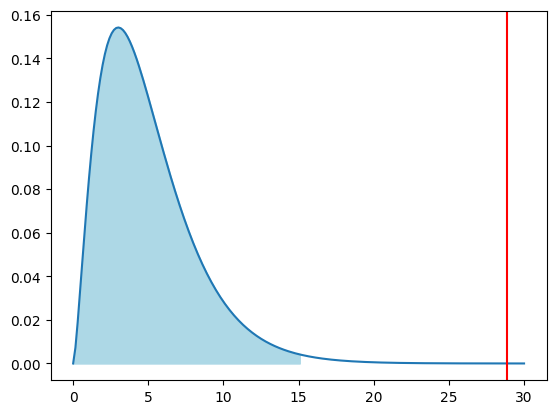

In [30]:
# x-values:
x = np.linspace(0, 30, num=200)
# probability density of the chi-squared distribution
y = stats.chi2.pdf(x, df=dof)
# the critical value g for which the right tail probability is exactly 1%:
g = stats.chi2.isf(alpha, df=dof)

plt.plot(x, y)                     # probability density
plt.fill_between(x, y, where=x<=g, # critical area
    color='lightblue')
plt.axvline(chi2, color='red');    # chi-squared

We conclude that this sample is NOT representative for the population!

The formula for calculating **standardised residuals** is:

$r_i = \frac{o_i-e_i}{\sqrt{e_i (1-\pi_i)}}$

We will add these to our data frame in a new column:

In [31]:
families['stdres'] = (families.observed - families.expected) / np.sqrt(families.expected * (1 - families.expected_p))
families

,num_boys,observed,expected_p,expected,stdres
0,0,58,0.03125,31.9375,4.685541
1,1,149,0.15625,159.6875,-0.920733
2,2,305,0.31250,319.3750,-0.970110
3,3,303,0.31250,319.3750,-1.105082
4,4,162,0.15625,159.6875,0.199223
5,5,45,0.03125,31.9375,2.348389


Standardised residuals are a measure of the extent to which a certain category is over- or under-represented in the sample. A value of 0 is given when the observed frequency is equal to the expected frequency. A negative value is given when there are fewer observations than expected and a positive value when there are more. As long as $r_i \in [-2, 2]$, we consider the differences to be random sampling errors. A value $r_i < -2$ indicates underrepresentation of this category, $r_i > 2$ indicates overrepresentation.

Thus, families with only girls and only boys are over-represented in the sample. In practice, researchers could choose to randomly remove a number of observations in these categories from the study, so that the sample becomes representative of the population.

Remark that there is a way to calculate standardized residuals using [`statsmodels.stats.contingency_tables.Table`](https://www.statsmodels.org/stable/generated/statsmodels.stats.contingency_tables.Table.html#statsmodels.stats.contingency_tables.Table). However, that only works with [contingency tables for two variables](https://www.statsmodels.org/stable/contingency_tables.html?highlight=residuals), not for this case with one variable.

## Cochran's rule

A chi-squared test can only give good results if you have enough observations in each category. The statistician Cochran (1954) formulated a rule of thumb to determine what exactly *enough* is on contingency tables larger than 2x2:

1. All expected values must be at least 1
2. At most 20% of the expected values may be smaller than 5

Consequently, if a contingency table does *not* meet these criteria, the results of the chi-squared test may not be reliable!
